# ARIA v3.0
本系統整合：
- Week 3 河川風險
- Week 4 地形風險
- Week 5 即時 / 模擬雨量資料

目標：
建立動態災害風險監測系統。

### 安裝與載入套件

In [10]:
import os
import json
import requests
import pandas as pd
import geopandas as gpd
import folium

from folium.plugins import HeatMap
from shapely.geometry import Point
from dotenv import load_dotenv

### 讀取.env

In [15]:
load_dotenv()

APP_MODE = os.getenv("APP_MODE")
API_KEY = os.getenv("CWA_API_KEY")
SIMULATION_DATA = os.getenv("SIMULATION_DATA")

PROJECT_CRS = int(os.getenv("PROJECT_CRS"))
RAIN_WARNING = float(os.getenv("RAIN_WARNING"))
RAIN_CRITICAL = float(os.getenv("RAIN_CRITICAL"))
BUFFER_DISTANCE = float(os.getenv("BUFFER_DISTANCE"))

print(APP_MODE)

SIMULATION


In [18]:
SIMULATION_DATA = r"C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week5\data\fungwong_202511.json"
SIMULATION_DATA

'C:\\Users\\vicky\\Desktop\\NTU\\GA 遙測與空間資訊之分析與應用\\windsurf-project\\week5\\data\\fungwong_202511.json'

### 模式切換器（作業核心）

In [19]:
def fetch_live_data(api_key):
    url = (
        f"https://opendata.cwa.gov.tw/api/v1/rest/datastore/"
        f"O-A0002-001?Authorization={api_key}&format=JSON"
    )

    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return resp.json()

    except Exception as e:
        print("LIVE API failed, fallback to simulation")
        with open(SIMULATION_DATA, "r", encoding="utf-8") as f:
            return json.load(f)


def load_simulation_data(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


if APP_MODE == "LIVE":
    raw_data = fetch_live_data(API_KEY)
else:
    raw_data = load_simulation_data(SIMULATION_DATA)

print("Data loaded")

Data loaded


### normalize 函數

In [20]:
def normalize_cwa_json(data):
    stations = data["records"]["Station"]
    normalized = []

    for s in stations:
        try:
            coords = s["GeoInfo"]["Coordinates"]

            if len(coords) >= 2:
                lon = float(coords[1]["StationLongitude"])
                lat = float(coords[1]["StationLatitude"])
            else:
                lon = float(coords[0]["StationLongitude"])
                lat = float(coords[0]["StationLatitude"])

            rain = s["RainfallElement"]["Past1hr"]["Precipitation"]
            rain = float(rain)

            if rain == -998:
                continue

            normalized.append({
                "station_name": s["StationName"],
                "lat": lat,
                "lon": lon,
                "rain_1hr": rain
            })

        except Exception:
            continue

    return normalized

### 建立雨量站 GeoDataFrame

In [21]:
stations = normalize_cwa_json(raw_data)

rain_df = pd.DataFrame(stations)

rain_gdf = gpd.GeoDataFrame(
    rain_df,
    geometry=gpd.points_from_xy(
        rain_df["lon"],
        rain_df["lat"]
    ),
    crs="EPSG:4326"
)

rain_gdf.head()

,station_name,lat,lon,rain_1hr,geometry
0,國一S072K,24.895830,121.134200,0.0,POINT (121.1342 24.89583)
1,馬光農場,23.721453,120.378864,0.0,POINT (120.37886 23.72145)
2,出雲,24.206469,120.902794,0.0,POINT (120.90279 24.20647)
3,頭櫃山,24.129842,120.858925,0.0,POINT (120.85892 24.12984)
4,三隻寮,24.093078,120.861578,0.0,POINT (120.86158 24.09308)


### 轉 CRS + buffer

In [22]:
rain_gdf_3826 = rain_gdf.to_crs(epsg=3826)

rain_gdf_3826["buffer_geom"] = (
    rain_gdf_3826.geometry.buffer(BUFFER_DISTANCE)
)

rain_buffer = gpd.GeoDataFrame(
    rain_gdf_3826.drop(columns="geometry"),
    geometry="buffer_geom",
    crs="EPSG:3826"
)

### 避難所資料（W3-W4 成果）

In [29]:
shelters_path = r"C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week4_vector_raster\Homework\outputs\ARIA_v2_shelters_enhanced.gpkg"
shelters_path

'C:\\Users\\vicky\\Desktop\\NTU\\GA 遙測與空間資訊之分析與應用\\windsurf-project\\week4_vector_raster\\Homework\\outputs\\ARIA_v2_shelters_enhanced.gpkg'

In [30]:
import geopandas as gpd
shelters = gpd.read_file(shelters_path)

# 檢查 CRS
print("Original CRS:", shelters.crs)

# 轉成分析用 CRS（EPSG:3826）
shelters = shelters.to_crs(epsg=3826)

# 查看資料
shelters.head()

Original CRS: EPSG:3826


,shelter_id,name,capacity,indoor,river_distance_category,mean_elevation,max_slope,mean_slope,std_elevation,risk_level,geometry
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.994240,High,POINT (326011.111 2689346.508)
1,1305,豐南社區活動中心,50,是,High,299.459141,41.046368,7.969157,13.260633,Critical,POINT (277505.779 2560143.417)
2,1331,玉寶宮,20,是,High,240.630896,29.891891,4.557448,7.838210,High,POINT (274563.447 2562153.682)
3,1341,永豐社區活動中心,50,是,High,257.456832,32.286247,7.956691,22.753039,Critical,POINT (276261.145 2563286.086)
4,1349,富里老人文康中心,100,是,High,238.324352,30.526333,5.579786,18.284005,Critical,POINT (275351.804 2563630.784)


### 8：Spatial Join

In [31]:
# CRS double check
assert str(shelters.crs) == str(rain_buffer.crs), "CRS MISMATCH!"

# spatial join
affected = gpd.sjoin(
    shelters,
    rain_buffer,
    how="left",
    predicate="intersects"
)

print(f"受暴雨影響避難所數量: {affected['rain_1hr'].notna().sum()}")

affected.head()

受暴雨影響避難所數量: 702


,shelter_id,name,capacity,indoor,river_distance_category,mean_elevation,max_slope,mean_slope,std_elevation,risk_level,geometry,index_right,station_name,lat,lon,rain_1hr
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.99424,High,POINT (326011.111 2689346.508),514.0,和中,24.266761,121.741031,0.0
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.99424,High,POINT (326011.111 2689346.508),876.0,和中,24.270832,121.741801,0.0
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.99424,High,POINT (326011.111 2689346.508),69.0,秀林,24.302863,121.731144,1.0
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.99424,High,POINT (326011.111 2689346.508),1065.0,和平,24.307169,121.770069,0.5
0,45,和平國小,250,是,Medium,27.502352,45.473251,6.176926,17.99424,High,POINT (326011.111 2689346.508),842.0,大濁水,24.329422,121.739594,0.0


### 9：動態風險分級

In [32]:
def classify_risk(row):
    rain = row["rain_1hr"]
    terrain = row["risk_level"]

    if pd.isna(rain):
        return "SAFE"

    if rain > 80:
        return "CRITICAL"

    elif rain > 40 and terrain in ["High", "Critical"]:
        return "URGENT"

    elif rain > 40 or terrain in ["High", "Critical"]:
        return "WARNING"

    else:
        return "SAFE"


affected["dynamic_risk"] = affected.apply(
    classify_risk,
    axis=1
)

affected[["name", "risk_level", "rain_1hr", "dynamic_risk"]].head()

,name,risk_level,rain_1hr,dynamic_risk
0,和平國小,High,0.0,WARNING
0,和平國小,High,0.0,WARNING
0,和平國小,High,1.0,WARNING
0,和平國小,High,0.5,WARNING
0,和平國小,High,0.0,WARNING


### 10：Folium 地圖

In [35]:
affected_4326 = affected.to_crs(epsg=4326)

map_center = [23.987, 121.601]

m = folium.Map(
    location=map_center,
    zoom_start=9
)

risk_color = {
    "SAFE": "green",
    "WARNING": "yellow",
    "URGENT": "orange",
    "CRITICAL": "red"
}

for _, row in affected_4326.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=(
            f"{row['name']}<br>"
            f"Terrain: {row['risk_level']}<br>"
            f"Rain: {row['rain_1hr']} mm<br>"
            f"Dynamic Risk: {row['dynamic_risk']}"
        ),
        icon=folium.Icon(
            color=risk_color[row["dynamic_risk"]]
        )
    ).add_to(m)



C:\Users\vicky\AppData\Local\Temp\ipykernel_16656\2328306007.py:26: UserWarning: color argument of Icon should be one of: {'purple', 'white', 'darkgreen', 'lightgray', 'green', 'darkpurple', 'lightred', 'darkblue', 'pink', 'black', 'blue', 'red', 'cadetblue', 'lightgreen', 'orange', 'lightblue', 'darkred', 'beige', 'gray'}.
  icon=folium.Icon(


### 11：雨量圖層

In [36]:
for _, row in rain_gdf.iterrows():

    rain = row["rain_1hr"]

    if rain > 80:
        color = "red"
    elif rain > 40:
        color = "orange"
    elif rain > 20:
        color = "yellow"
    else:
        color = "green"

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=max(rain / 10, 3),
        popup=f"{row['station_name']}: {rain} mm",
        color=color,
        fill=True
    ).add_to(m)

### 12：避難所圖層

In [37]:
risk_color = {
    "SAFE": "green",
    "WARNING": "yellow",
    "URGENT": "orange",
    "CRITICAL": "red"
}

affected_4326 = affected.to_crs(epsg=4326)

for _, row in affected_4326.iterrows():

    folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        popup=(
            f"{row['name']}<br>"
            f"Risk: {row['dynamic_risk']}"
        ),
        icon=folium.Icon(
            color=risk_color[row["dynamic_risk"]]
        )
    ).add_to(m)

C:\Users\vicky\AppData\Local\Temp\ipykernel_16656\1766707299.py:21: UserWarning: color argument of Icon should be one of: {'purple', 'white', 'darkgreen', 'lightgray', 'green', 'darkpurple', 'lightred', 'darkblue', 'pink', 'black', 'blue', 'red', 'cadetblue', 'lightgreen', 'orange', 'lightblue', 'darkred', 'beige', 'gray'}.
  icon=folium.Icon(


### 13：HeatMap

In [38]:
heat_data = [
    [r["lat"], r["lon"], r["rain_1hr"]]
    for _, r in rain_gdf.iterrows()
]

HeatMap(heat_data).add_to(m)

### 14：儲存

In [41]:
output_path = "output/ARIA_v3_Fungwong.html"

m.save(output_path)

print(f"Saved: {output_path}")

Saved: output/ARIA_v3_Fungwong.html


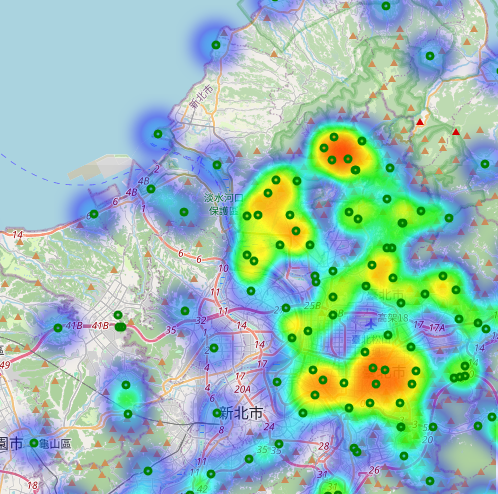

![image2.png](<attachment:螢幕擷取畫面 2026-03-30 192022.png>)
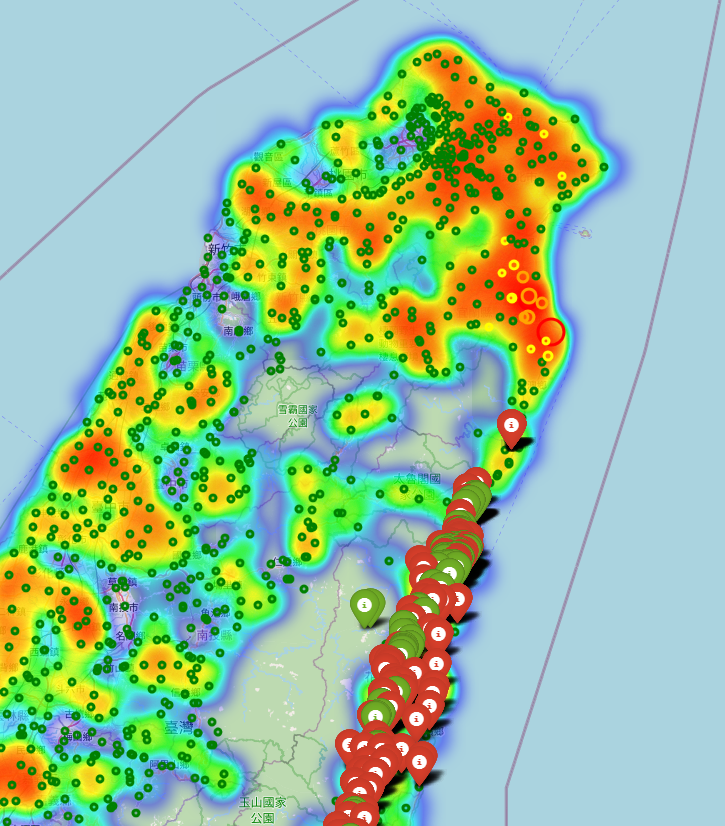